# Automated ETL Pipeline for Housing Data Preprocessing

## 📌 Objective
The objective of this project is to design and implement an automated ETL (Extract, Transform, Load) pipeline for preparing raw housing data for machine learning applications.

The pipeline performs the following tasks:

1. **Extract** raw data from a CSV file.
2. **Transform** the data by:
   - Handling missing values
   - Removing duplicate records
   - Standardizing inconsistent text values
   - Converting mixed data types
   - Detecting and removing outliers
   - Encoding categorical variables
   - Scaling numerical features
3. **Load** the cleaned dataset into a new CSV file.
4. Train a machine learning model using the processed data.

---

## 🏠 Problem Statement
Real-world datasets are often messy and contain:
- Missing values
- Duplicate rows
- Inconsistent categorical labels
- Mixed data types
- Extreme outliers

These issues reduce data quality and negatively impact model performance.

This project simulates a real-world scenario by working with a deliberately messy housing dataset and building a reusable preprocessing pipeline using:

- `pandas`
- `numpy`
- `scikit-learn`

---

## 🛠 Tools and Technologies Used

| Tool | Purpose |
|------|--------|
| Pandas | Data extraction, cleaning, and manipulation |
| NumPy | Numerical operations |
| Matplotlib & Seaborn | Exploratory Data Analysis (EDA) |
| Scikit-learn | Preprocessing pipelines and model training |
| Jupyter Notebook | Development and documentation |

---

## 🔄 ETL Workflow

### 1. Extract
- Load raw housing data from a CSV file.

### 2. Transform
- Perform Exploratory Data Analysis (EDA)
- Handle missing values
- Remove duplicate rows
- Standardize text values (e.g., Delhi, delhi, DELHI)
- Convert mixed formats (e.g., 3BHK → 3)
- Detect and remove outliers
- Encode categorical variables
- Scale numerical features

### 3. Load
- Save the cleaned dataset to a new CSV file.

### 4. Machine Learning Integration
- Use the processed dataset to train a predictive model.

---

## 📊 Expected Outcomes
By the end of this project:

- A fully automated ETL pipeline will be created.
- Raw, inconsistent data will be transformed into a clean dataset.
- The cleaned data will be ready for machine learning.
- A trained model will demonstrate successful end-to-end processing.

---

## 🎯 Learning Outcomes
This project demonstrates practical understanding of:

- Data preprocessing
- Feature engineering
- ETL automation
- Scikit-learn Pipelines
- Production-ready machine learning workflows

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("housing.csv")

## Analyzing the Data (EDA)

**Exploratory Data Analysis (EDA)** is the process of examining a dataset to summarize its main characteristics, often using visual methods or quick commands to understand the structure of the data, detect patterns, spot anomalies, and get a feel for what kind of preprocessing or modeling might be needed.

In [3]:
data.head()  
# Displays the first 5 rows of the dataset.
# Useful for getting a quick overview of what the data looks like — column names, data types, and sample values

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.tail()
# Displays the last 5 rows of the dataset.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
data.info()
# Gives a summary of the dataset.
# Shows the number of entries, column names, data types, and how many nonnull values each column has.
# Helps us identify missing values or incorrect data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
import numpy as np

In [9]:
def shuffle_and_split_data(data,test_ratio):
    np.random.seed(42) # Set the seed for reproducibility -- NumPy generates the same random numbers each time the code is run, creating the same train-test split each time.
    shuffled_indices = np.random.permutation(len(data))
    test_size = int(len(data)*test_ratio)
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [10]:
# train,test = shuffle_and_split_data(data,0.3)

## ⚠️ Limitation of Random Splitting Without Stratification

The custom `shuffle_and_split_data()` function randomly shuffles the dataset and divides it into training and testing sets. While this approach ensures reproducibility by fixing the random seed, it has an important limitation: **it does not perform stratified sampling**.

### What Is the Problem?

In many real-world datasets, certain groups or categories may be underrepresented. For example:

- Some cities may appear much more frequently than others.
- Expensive houses may be rare compared to average-priced houses.
- Certain property types may have very few examples.

A purely random split may create training and testing sets with different proportions of these groups. As a result:

- The test set may not accurately represent the overall dataset.
- Model performance estimates may become unreliable.
- Rare but important categories may be missing from either the training or test set.

### Example

Suppose 20% of houses are located in Mumbai and 80% are located in Delhi.

A random split might produce:

- Training set: 90% Delhi, 10% Mumbai
- Test set: 70% Delhi, 30% Mumbai

This imbalance can lead to biased evaluation results.

### Why Stratified Sampling Is Better

Stratified sampling ensures that both the training and testing sets preserve the same distribution of important categories as the original dataset.

For example, if Mumbai represents 20% of the full dataset, it will also represent approximately 20% of both the training and testing sets.

### Conclusion

Although the custom random split function works correctly, it may produce unrepresentative training and testing sets. Stratified sampling is preferred when the dataset contains important groups or categories that should be proportionally represented in both subsets.

##### the California housing dataset, median income is a strong predictor of house prices. Instead of randomly sampling, we can create strata based on income levels (e.g., binning median income into categories) and ensure the test set maintains the same distribution of income levels as the full dataset.

##### create a new column income_cat that categorizes the median_income into five bins. Each bin represents a range of income levels, allowing us to stratify our sampling based on these categories.


In [11]:
data = pd.read_csv("housing.csv")
data["income_cat"] = pd.cut(data["median_income"],
                            bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                            labels=[1, 2, 3, 4, 5])

Text(0, 0.5, 'Number of Instances')

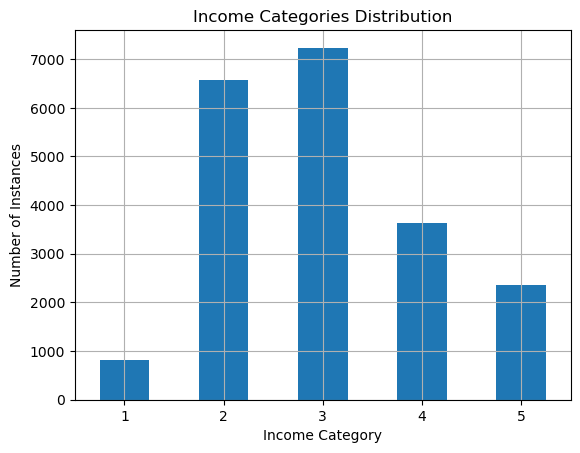

In [12]:
import matplotlib.pyplot as plt
data["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

#### Stratified Shuffle Split in Scikit-Learn

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data,data["income_cat"]):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]
    

### Improved Train-Test Splitting Using Stratified Sampling

Initially, a custom function was used to randomly shuffle and split the dataset. However, this method did not guarantee that important categories were proportionally represented in both the training and testing sets.

To solve this issue, `StratifiedShuffleSplit` from scikit-learn was used. This method preserves the distribution of the `income_cat` feature across both subsets, ensuring that the train and test sets remain representative of the overall dataset.